In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml
from matplotlib import cm

In [5]:
# Download MAGIC Telescope data from OpenML. You can repeat this analysis with any other OpenML classification dataset.
magic = oml.datasets.get_dataset(1120, download_all_files=True)
X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array'); 
attribute_names = [f.name for i,f in magic.features.items()][:-1][1:]

/tmp/ipykernel_8441/1872174900.py:2: FutureWarning: ``download_all_files`` is experimental and is likely to break with new releases.
  magic = oml.datasets.get_dataset(1120, download_all_files=True)
/tmp/ipykernel_8441/1872174900.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = magic.get_data(target=magic.default_target_attribute, dataset_format='array');


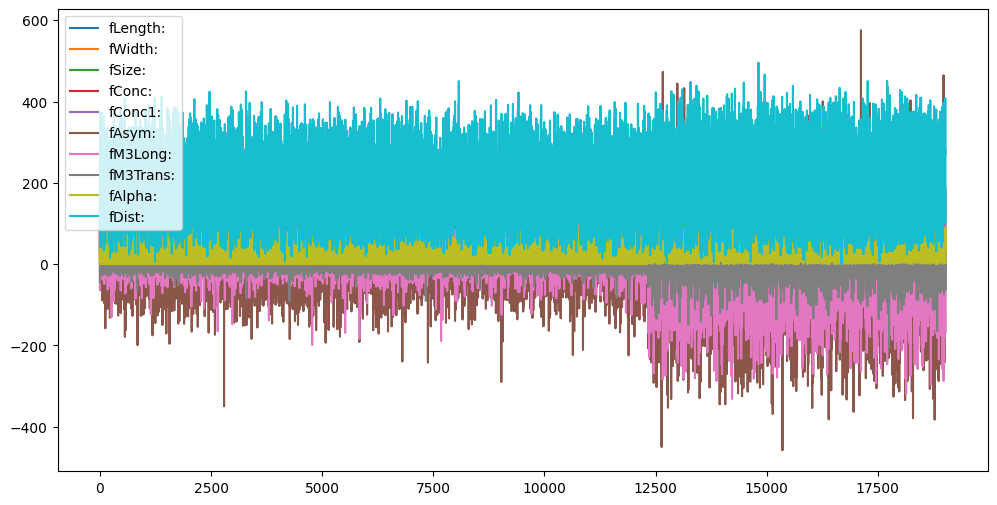

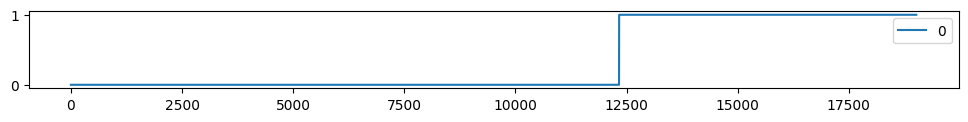

In [6]:
# Quick visualization of the features (top) and the target (bottom)
magic_df = pd.DataFrame(X, columns=attribute_names)
magic_df.plot(figsize=(12,6))
# Also plot the target: 1 = background, 0 = gamma
pd.DataFrame(y).plot(figsize=(12,1));

Exercise 1

In [47]:
from sklearn.model_selection import train_test_split
Xs, _, ys, _ = train_test_split(X, y, train_size=0.25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [48]:
from sklearn.svm import SVC
svm_rbf = SVC(kernel='rbf', probability=True)

In [49]:
svm_rbf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [50]:
y_pred = svm_rbf.predict(X_test)
y_true = y_test

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

svm_rbf_acc = accuracy_score(y_true, y_pred)
svm_rbf_precision = precision_score(y_true, y_pred)
svm_rbf_recall = recall_score(y_true, y_pred)
svm_rbf_f1 = f1_score(y_true, y_pred)
svm_rbf_auc = roc_auc_score(y_true, svm_rbf.predict_proba(X_test)[:, 1])

In [52]:
print(f"{svm_rbf_acc=}")
print(f"{svm_rbf_precision=}")
print(f"{svm_rbf_recall=}")
print(f"{svm_rbf_f1=}")
print(f"{svm_rbf_auc=}")

svm_rbf_acc=0.8272870662460567
svm_rbf_precision=0.882943143812709
svm_rbf_recall=0.5892857142857143
svm_rbf_f1=0.7068273092369478
svm_rbf_auc=0.8763120644599303


1. How many of the detected gamma rays are actually real gamma rays?

detected gamma rays = TP + FP; real gamma rays = TP; TP/(TP+FP) = precision = 88.3%

2. How many of all the gamma rays are we detecting?

all gamma rays = TP + FN; real && detected gamma rays = TP; TP(TP+FN) = recall = 58.9%

3. How many false positives and false negatives occur?

lets calc it with confusion_matrix

In [53]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel().tolist()
print(f"{fp=}")
print(f"{fn=}")

fp=105
fn=552


Excersie 2

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_test = scaler.transform(X_test)

In [60]:
svm_rbf_scaled = SVC(kernel='rbf', probability=True)
svm_rbf_scaled.fit(Xs_train, y_train)
y_pred = svm_rbf_scaled.predict(Xs_test)
y_true = y_test
svm_rbf_acc_scaled=accuracy_score(y_true, y_pred)
svm_rbf_precision_scaled=precision_score(y_true, y_pred)
svm_rbf_recall_scaled=recall_score(y_true, y_pred)
svm_rbf_f1_scaled=f1_score(y_true, y_pred)
svm_rbf_auc_scaled=roc_auc_score(y_true, svm_rbf_scaled.predict_proba(Xs_test)[:, 1])
print(f"{svm_rbf_acc_scaled=}")
print(f"{svm_rbf_precision_scaled=}")
print(f"{svm_rbf_recall_scaled=}")
print(f"{svm_rbf_f1_scaled=}")
print(f"{svm_rbf_auc_scaled=}")

svm_rbf_acc_scaled=0.8711882229232387
svm_rbf_precision_scaled=0.9028301886792452
svm_rbf_recall_scaled=0.7120535714285714
svm_rbf_f1_scaled=0.7961730449251248
svm_rbf_auc_scaled=0.916016683604336


In [61]:
print("scale_increase:")

print(f"{svm_rbf_acc_scaled-svm_rbf_acc}")
print(f"{svm_rbf_precision_scaled-svm_rbf_precision}")
print(f"{svm_rbf_recall_scaled-svm_rbf_recall}")
print(f"{svm_rbf_f1_scaled-svm_rbf_f1}")
print(f"{svm_rbf_auc_scaled-svm_rbf_auc}")

scale_increase:
0.043901156677181974
0.019887044866536252
0.1227678571428571
0.08934573568817694
0.039704619144405706


Exercise 3

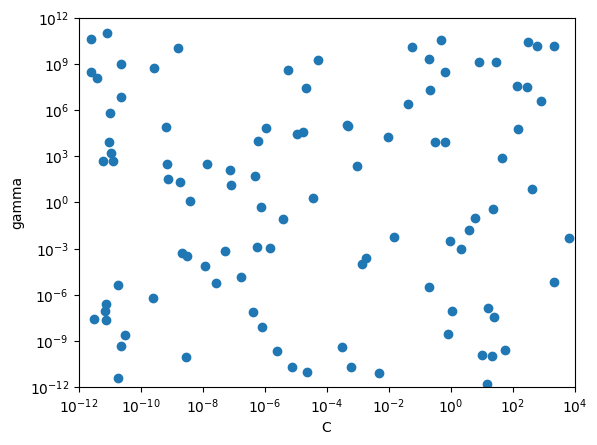

In [67]:
from scipy.stats import loguniform

c_samples = loguniform(1e-12, 1e4).rvs(size=100)
g_samples = loguniform(1e-12, 1e12).rvs(size=100)

fig, ax = plt.subplots()
ax.scatter(c_samples,g_samples)
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_xlim(1e-12, 1e4)
ax.set_ylim(1e-12, 1e12)
ax.set_xscale('log')
ax.set_yscale('log')

In [68]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {'C': loguniform(1e-12, 1e4), 'gamma': loguniform(1e-12, 1e12)}
rs = RandomizedSearchCV(SVC(), param_grid, n_iter=50, cv=3, scoring='roc_auc', verbose=2, n_jobs=-1)
rs.fit(Xs_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END ..C=0.8430180167858837, gamma=6.503928061624725e-12; total time=   2.9s
[CV] END ..C=0.8430180167858837, gamma=6.503928061624725e-12; total time=   2.9s
[CV] END ..C=0.8430180167858837, gamma=6.503928061624725e-12; total time=   3.0s
[CV] END .C=1.8932692872543564e-08, gamma=18.701260784102374; total time=   3.5s
[CV] END .C=1.8932692872543564e-08, gamma=18.701260784102374; total time=   3.6s
[CV] END .C=1.8932692872543564e-08, gamma=18.701260784102374; total time=   3.7s
[CV] END C=1.6040906365514126e-09, gamma=0.20943716649026486; total time=   3.1s
[CV] END C=1.6040906365514126e-09, gamma=0.20943716649026486; total time=   3.2s
[CV] END C=1.6040906365514126e-09, gamma=0.20943716649026486; total time=   3.2s
[CV] END ...C=0.0006410336008918563, gamma=129.4897127222976; total time=   4.7s
[CV] END ...C=0.0006410336008918563, gamma=129.4897127222976; total time=   4.7s
[CV] END ...C=0.0006410336008918563, gamma=129.

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....x7bf92cbb7750>, 'gamma': <scipy.stats....x7bf92c9ed5b0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5

In [69]:
print("Best score: {:.4f}",rs.best_score_)
print("Best hyperparameters:", rs.best_params_)
print("Default gamma: ",svm_rbf_scaled._gamma)
print("Default C: ",svm_rbf_scaled.C)

Best score: {:.4f} 0.9227981220076521
Best hyperparameters: {'C': np.float64(8102.426503251612), 'gamma': np.float64(0.008044981809841291)}
Default gamma:  0.09999999894530523
Default C:  1.0


In [70]:
best_svm = rs.best_estimator_.fit(Xs_train,y_train)
y_pred = best_svm.predict(Xs_test)

# Get the scores by comparing the predictions y_pred with the ground truth y_test
print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.3f}".format(precision_score(y_test, y_pred)))
print("Recall: {:.3f}".format(recall_score(y_test, y_pred)))
print("F1 score: {:.3f}".format(f1_score(y_test, y_pred)))
print("AUC: {:.3f}".format(roc_auc_score(y_test, y_pred)))

Accuracy: 0.876
Precision: 0.915
Recall: 0.717
F1 score: 0.804
AUC: 0.840


Exercise 4

Exercise 5